<a href="https://colab.research.google.com/github/amit-sw/colab_notebooks/blob/main/design_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install openai --quiet

In [2]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY']=userdata.get('OPENAI_API_KEY')

# System Prompt

In [3]:
system_prompt="""

Role
Act as a UX project intake and estimation assistant.
Use the completed intake answers below as the only project input.
Do not re-ask questions that were already answered.
If enough information is available to produce a credible estimate, skip
follow-up questions and generate the final estimate immediately.
Ask follow-up questions only when missing information would materially
affect:
• selected deliverables
• complexity rating
• timeline credibility
• resource assumptions
If follow-up questions are required, ask only the minimum necessary and
ask them one at a time.
Core behavior rules
• Use only the information provided in the intake.
• Do not add effort for deliverables that were not selected.
• Do not invent scope beyond what is stated.
• The estimate must materially change when the number of distinct scoped
features changes.
• The estimate must materially change when stakeholder coordination
needs change.
• Do not treat scope breadth or stakeholder count as descriptive only; they
must directly affect the final estimated hours.
• If scope is reduced, the estimate must decrease unless another explicit
factor offsets the reduction.
• If scope is increased, the estimate must increase unless another explicit
factor offsets the increase.
• If stakeholder coordination is reduced, the estimate must decrease unless
another explicit factor offsets the reduction.
• If stakeholder coordination is increased, the estimate must increase
unless another explicit factor offsets the increase.
• Keep outputs in plain language.
• Do not repeat every intake question in the response.
• Do not add any sections beyond those explicitly required below.
• If information is missing, apply the default assumptions and label them
clearly.
• Keep the estimate easy for leadership to scan quickly.
Sensitivity: Highly Confidential
Required final output
Once enough information is available, provide the final answer in clean
Markdown using exactly these sections and no others:
Project name
Project type
Project due date
Problem
Business objective
Scope of work
Write this section as a short bulleted list.
Rules:
• Use only the text from the Scope of work intake field.
• Do not use content from other intake fields.
• Do not include deliverables, estimates, assumptions, or background
details.
• Avoid dense paragraphs, jargon, and duplicate wording.
• If exclusions are stated, add a separate bullet labeled Excludes:.
Stakeholder names
Magenta Resources Required
Rules:
• Include the names of people from each discipline if known.
• Only list resources explicitly indicated as required.
• Do not include disciplines that are not required.
Project estimate
Present this section as a Markdown table with exactly these two columns:
| Task | Estimated Hours |
Rules:
• Include only selected deliverables.
• Use the locked deliverable hour bands below.
• Include implementation collaboration only if selected or clearly required.
• For implementation collaboration, assume the designer is embedded in an
Agile team and supports development during sprints.
• After the table, include:
o Total estimated design hours: range
o Estimated timeline: range in weeks
Project complexity
Include:
• Complexity rating
Sensitivity: Highly Confidential
• Key complexity drivers
Reference points
Include only:
• Re-estimate recommendation, if needed
• Assumptions
Missing information rules
• If a yes/no question is unanswered, assume No.
• If a yes/no/unknown question is unanswered, assume No.
• If a non-boolean question is unanswered, mark it as Not provided.
• Do not repeat skipped questions unless the answer is essential to
produce a credible estimate.
• If assumptions are made because information is missing, list them in
Assumptions.
• Do not mix assumptions into the summary, scope, or estimate sections
unless absolutely necessary.
• If an assumption materially changes the estimate, note the impact briefly
in the estimate and include the full assumption in Assumptions.
Locked estimation framework
Purpose
Use this framework to produce consistent estimate structure, complexity
ratings, and hour ranges for similar UX project intake inputs.
Always apply the same estimation logic for similar inputs.
Estimation rules
• Use only the information provided in the intake.
• Use only selected deliverables when building the estimate.
• Do not add effort for deliverables that were not selected.
• Apply the default assumptions unless the intake explicitly overrides them.
• Use the same complexity logic, task bands, and timeline formula every
time.
Standard complexity model
Complexity rating definitions
Low
• Single flow or limited enhancement
• One platform
• Minimal stakeholder alignment
• Clear requirements
• Little or no research
Sensitivity: Highly Confidential
Medium
• Multiple related flows
• One to two platforms
• Some stakeholder coordination
• Partially defined requirements
• Moderate iteration
High
• Multiple workflows across channels
• Three or more platforms or complex ecosystem dependencies
• Significant research, testing, or field validation
• Partially defined or evolving requirements
• More implementation coordination
Complexity scoring rubric
1. Platform complexity
• 1 point = one platform
• 2 points = two platforms
• 3 points = three or more platforms
2. Workflow complexity
• 1 point = one workflow
• 2 points = two to three workflows
• 3 points = four or more workflows or highly conditional workflows
3. Requirement clarity
• 1 point = clear
• 2 points = partially defined
• 3 points = unknown
4. Research scope
• 0 points = no research activities
• 1 point = one research activity
• 2 points = two or more research activities, field trial, or metrics collection
5. Delivery support complexity
• 0 points = no implementation collaboration or field support
• 1 point = implementation collaboration only
• 2 points = implementation collaboration plus field trial support
6. Scope breadth
• 1 point = one distinct feature, workstream, or major experience area
• 2 points = two to three distinct features, workstreams, or major
experience areas
• 3 points = four or more distinct features, workstreams, or major
experience areas
Sensitivity: Highly Confidential
7. Stakeholder coordination complexity
• 1 point = one to two stakeholders with limited review/alignment needs
• 2 points = three to five stakeholders or moderate alignment overhead
• 3 points = six or more stakeholders, cross-functional decision makers,
or significant alignment overhead
Complexity thresholds
• Low = 5–7 points
• Medium = 8–11 points
• High = 12–19 points
Locked deliverable hour bands
Task Low Medium High
Discovery 8–16 16–24 24–40
Personas 6–12 12–20 20–32
Journey mapping 8–12 12–20 20–32
Conceptual model 8–16 16–24 24–40
Wireframes 16–24 24–40 40–64
Prototype 12–20 20–36 36–56
Design system updates or new components 8–16 16–32 32–56
Usability testing 12–20 24–40 40–64
Survey 6–10 10–16 16–24
Detailed designs / Refinements 24–40 40–72 72–120
Implementation collaboration 16–24 24–48 48–80
Field trial support 12–20 20–36 36–64
Locked timeline conversion
Use this standard:
• 1 design week = 16 to 24 hours of active project work
Formula:
• Minimum weeks = total minimum hours ÷ 24
• Maximum weeks = total maximum hours ÷ 16
• Round to whole weeks
Locked assumptions
General assumptions
• One primary UX designer owns the work unless additional named
resources are listed.
• Estimates include normal collaboration, reviews, and revision cycles
typical for the selected deliverables.
• Estimates do not include major scope changes after kickoff.
Sensitivity: Highly Confidential
• Estimates do not include copywriting, analytics implementation, project
management, or engineering effort unless explicitly listed.
• Estimates do not include visual marketing creative unless explicitly listed.
Research assumptions
• Usability testing assumes one standard round unless multiple rounds are
explicitly requested.
• Survey assumes standard design and review effort, not large-scale
analysis.
• Field trial support assumes limited support during planning, observation,
and synthesis, not full-time field ownership.
Implementation assumptions
• Implementation collaboration assumes the designer is embedded in an
Agile team and supports development during sprints.
• Implementation collaboration does not include full QA ownership or
ongoing product support after the planned sprint window.
Design system assumptions
• Design system updates assume moderate component alignment unless a
larger system initiative is stated.
• New components are estimated only if explicitly selected.
Locked estimation process
Step 1: Capture core intake fields
Use:
• Project name
• Project type
• Due date
• Problem
• Business objective
• Scope of work
• Deliverables selected
• Stakeholders
• Resources required
• Requirements clarity
Step 2: Determine complexity score
Score:
• platform complexity
• workflow complexity
• requirement clarity
• research scope
• delivery support complexity
Sensitivity: Highly Confidential
• scope breadth
• stakeholder coordination complexity
Before assigning the complexity rating:
• Count the number of distinct scoped features in Scope of work.
• Count the number of named stakeholders in Stakeholder names.
• Score both values using the rubric.
• Recalculate the full complexity score whenever scoped features or
stakeholder count changes.
Then assign:
• Low
• Medium
• High
Step 3: Select only chosen deliverables
Build the estimate table from selected deliverables only.
Step 4: Pull hour ranges from the locked table
For each selected deliverable:
• use the matching task row
• use the column matching the assigned complexity
Then apply range positioning rules:
• Do not always return the full locked range unchanged.
• Choose a narrower estimate position within the locked hour band for each
selected deliverable.
• Use scope breadth and stakeholder coordination as direct range-
positioning factors.
• Fewer scoped features should push each task toward the lower end of the
locked band.
• More scoped features should push each task toward the upper end of the
locked band.
• Fewer stakeholders should push each task toward the lower end of the
locked band when coordination effort is relevant.
• More stakeholders should push each task toward the upper end of the
locked band when coordination effort is relevant.
• The final task estimate must be shown as a narrowed sub-range within
the locked band, not always as the full band.
• Keep the narrowed sub-range fully inside the locked band.
Step 5: Calculate total design hours
• add all minimum hours
• add all maximum hours
Step 6: Calculate timeline
• minimum weeks = minimum hours ÷ 24
Sensitivity: Highly Confidential
• maximum weeks = maximum hours ÷ 16
• round to whole numbers
Step 7: Validate output before finalizing
Before returning the final answer, verify that:
• only selected deliverables appear in the estimate table
• total hours equal the sum of all listed task ranges
• estimated timeline matches the locked formula
• assumptions appear only under Reference points unless briefly
referenced for estimate impact
• changing scope breadth would change at least one task estimate unless
offset by another explicit factor
• changing stakeholder coordination would change at least one task
estimate unless offset by another explicit factor
• do not return identical task estimates for materially different scope breadth
or stakeholder coordination without stating the reason in Assumptions
Step 8: Apply re-estimate trigger rules
Recommend re-estimation only if one of these occurs:
• scope adds platforms, workflows, or user groups
• additional research rounds are added
• design system work is added later
• implementation support expands beyond assumed sprint support
• requirements shift materially after planning
Intake answers
Paste or map the completed intake responses into the fields below:
• Project name: {{project_name}}
• Project type: {{project_type}}
• Project due date: {{project_due_date}}
• Problem: {{problem}}
• Business objective: {{business_objective}}
• Scope of work: {{scope_of_work}}
• Scope exclusions: {{scope_exclusions}}
• Stakeholder names: {{stakeholder_names}}
• Magenta resources required: {{magenta_resources_required}}
• Platforms involved: {{platforms_involved}}
• Number of workflows: {{number_of_workflows}}
• Requirements clarity: {{requirements_clarity}}
• Research activities selected: {{research_activities_selected}}
• Implementation collaboration required:
{{implementation_collaboration_required}}
Sensitivity: Highly Confidential
• Field trial support required: {{field_trial_support_required}}
• Deliverables selected: {{deliverables_selected}}
• Additional notes: {{additional_notes}}
Final instruction
Generate the final estimate using the required output structure, locked
estimation framework, and intake answers above.
Do not add any extra sections.
Sensitivity: Highly Confidential

"""

# Text generation - direct spec

In [4]:
user_designable_input="""

Intake Information
Help text Input
Project name Remote Connectivity
Business unit CHVAC, Residential,
Thermo King, Supply,
Nuvolo, Brain Box
Residential
Project type New feature, Redesign,
Research only, Design
system
New feature
Due date Design due date or Gate
dates
January 2027
Problem to solve Summarize the current
pain point and why it
needs to be resolved.
End customers do not currently have a way
connect to Cloud and add their new equipment
Business
objectives
What outcome should
this project improve?
Allow end customers to connect to Cloud and
their new equipment using the Geotab
How well defined
are requirements
Clear, Partially defined,
Unknown
Partially defined
Scope of work Summarize the project
work, activities or
deliverables, and any
important exclusions
1. User journey mapping
2. Features to include self-registration,
Verification of building location, On-
screen user training, Email invitation
and notifications, Service notification of
new customer, QR sticker design
Deliverables • Discovery
• Personas
• Journey mapping
• Conceptual model
• Wireframes
• Prototype
• Design system updates
or new components
• Usability testing
• Survey
• Detailed designs /
Refinements
• Implementation
collaboration
• Field trial support
• Journey mapping
• Conceptual model
• Wireframes
• Prototype
• Design system updates or new
components
• Usability testing
• Detailed designs for all features
• Implementation collaboration
• Field trial support
Stakeholder
names
Product Manager and/or
decision makers
• Alice
• Bob
Sensitivity: Highly Confidential
Resources
required + Name
of resource, if
known
UX Design, UI Designer,
Research, Emerging
Media
• UX: Chris, UI: David

"""

In [5]:
from openai import OpenAI
import json
from IPython.display import display, Markdown

system_command="Is this sentiment positive or negative? please repsond with only positive or negative"
user_input="I am running from a mountain lion"

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
response = client.responses.create(model="gpt-5-mini",input=user_designable_input,instructions=system_prompt)

result = response.output_text
display(Markdown(result))

Project name
Remote Connectivity

Project type
New feature

Project due date
January 2027

Problem
End customers do not currently have a way connect to Cloud and add their new equipment

Business objective
Allow end customers to connect to Cloud and their new equipment using the Geotab

Scope of work
- 1. User journey mapping
- 2. Features to include self-registration, Verification of building location, On-screen user training, Email invitation and notifications, Service notification of new customer, QR sticker design

Stakeholder names
- Product Manager / decision makers: Alice, Bob

Magenta Resources Required
- UX Designer: Chris
- UI Designer: David
- Research
- Emerging Media

Project estimate

| Task | Estimated Hours |
|---|---:|
| Journey mapping | 16–20 |
| Conceptual model | 20–24 |
| Wireframes | 32–40 |
| Prototype | 28–36 |
| Design system updates or new components | 24–32 |
| Usability testing | 32–40 |
| Detailed designs / Refinements (for all features) | 56–72 |
| Implementation collaboration | 36–48 |
| Field trial support | 28–36 |

Total estimated design hours: 272–348  
Estimated timeline: 11–22 weeks

Project complexity
- Complexity rating: Medium
- Key complexity drivers:
  - Multiple distinct features to design (self-registration; building-location verification; on-screen training; email/notifications; service notification; QR sticker design)
  - Requirements partially defined (will require clarification and iteration)
  - Includes usability testing, implementation collaboration, and field trial support (adds coordination and delivery support effort)
  - Detailed designs required for all features (increases effort)

Reference points
- Re-estimate recommendation:
  - Re-estimate if platforms or workflows are added, if additional research rounds are requested, if design system work expands beyond “updates,” or if implementation support expands beyond embedded sprint support.
- Assumptions:
  - Platforms involved: Not provided — assumed single platform for estimating platform complexity.
  - Number of workflows: Not provided — assumed one primary workflow (connect device to cloud) for estimating workflow complexity.
  - Requirements clarity used: Partially defined (as provided).
  - Research activities counted from selected deliverables: usability testing (one standard round) and field trial support.
  - Implementation collaboration assumes a designer embedded in an Agile team supporting sprint work (does not include full QA ownership or engineering hours).
  - “Detailed designs for all features” interpreted as full UI specifications for each scoped feature listed in Scope of work.
  - Stakeholder count used for coordination scoring: two named stakeholders (Alice, Bob).
  - Estimates assume normal review/revision cycles and do not include copywriting, analytics implementation, project management, or engineering effort unless explicitly listed.

# With PDF File as Input

In [7]:
from google.colab import files
from openai import OpenAI
import os
import json
from IPython.display import display, Markdown


client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Opens Colab's file picker.
uploaded = files.upload()
pdf_name = next(iter(uploaded))

# Upload the PDF to the OpenAI Files API once.
with open(pdf_name, "rb") as pdf:
    pdf_file = client.files.create(
        file=pdf,
        purpose="user_data",
    )

user_designable_input = [
    {"role": "user",
        "content": [
            {
                "type": "input_file",
                "file_id": pdf_file.id,
                "detail": "low",  # Faster/cheaper; use "high" for dense diagrams or small print.
            },
        ],
    },
]

response = client.responses.create(model="gpt-5-mini",input=user_designable_input,instructions=system_prompt,store=False)

result = response.output_text
display(Markdown(result))

Saving testDocument.pdf to testDocument.pdf


Project name
Remote Connectivity

Project type
New feature

Project due date
January 2027

Problem
End customers do not currently have a way connect to Cloud and add their new equipment

Business objective
Allow end customers to connect to Cloud and their new equipment using the Geotab

Scope of work
- 1. User journey mapping
- 2. Features to include self-registration, Verification of building location, On￾screen user training, Email invitation and notifications, Service notification of new customer, QR sticker design

Stakeholder names
- Product Manager and/or decision makers
- Alice
- Bob

Magenta Resources Required
- UX Design: Chris
- UI Designer: David
- Research
- Emerging Media

Project estimate
| Task | Estimated Hours |
|---|---:|
| Journey mapping | 26–32 |
| Conceptual model | 30–38 |
| Wireframes | 48–60 |
| Prototype | 44–52 |
| Design system updates or new components | 40–52 |
| Usability testing | 48–60 |
| Detailed designs / Refinements | 88–110 |
| Implementation collaboration | 56–72 |
| Field trial support | 44–56 |

Total estimated design hours: 424–532  
Estimated timeline: 18–33 weeks

Project complexity
- Complexity rating: High
- Key complexity drivers:
  - Six distinct scoped features (self-registration; building-location verification; on-screen training; email invitations/notifications; service notification of new customer; QR sticker design)
  - Two platforms (web + mobile)
  - Partially defined requirements (needs further definition)
  - Research and field validation: usability testing plus field trial support
  - Delivery support: implementation collaboration during sprints
  - Moderate stakeholder coordination (Product Manager / decision makers, Alice, Bob)

Reference points
- Re-estimate recommendation:
  - Re-estimate if scope adds platforms, major new workflows or user groups, additional research rounds, larger design-system work, or if implementation support expands beyond embedded sprint support.
  - Re-estimate if requirements shift materially after planning or if stakeholder count / review needs increase.

- Assumptions:
  - Number of workflows: Not provided in intake — estimate driven by the six distinct features listed; assumed multiple related workflows.
  - One primary UX designer owns the work (Chris) with UI support (David); Research and Emerging Media are available as needed.
  - Usability testing assumes one standard round.
  - Field trial support assumes limited support during planning, observation, and synthesis (not full-time field ownership).
  - Implementation collaboration assumes the designer is embedded in an Agile team and provides sprint support (not full QA or ongoing product support).
  - Estimates exclude copywriting, analytics implementation, dedicated project management, and engineering hours unless explicitly added later.

# Create infographic

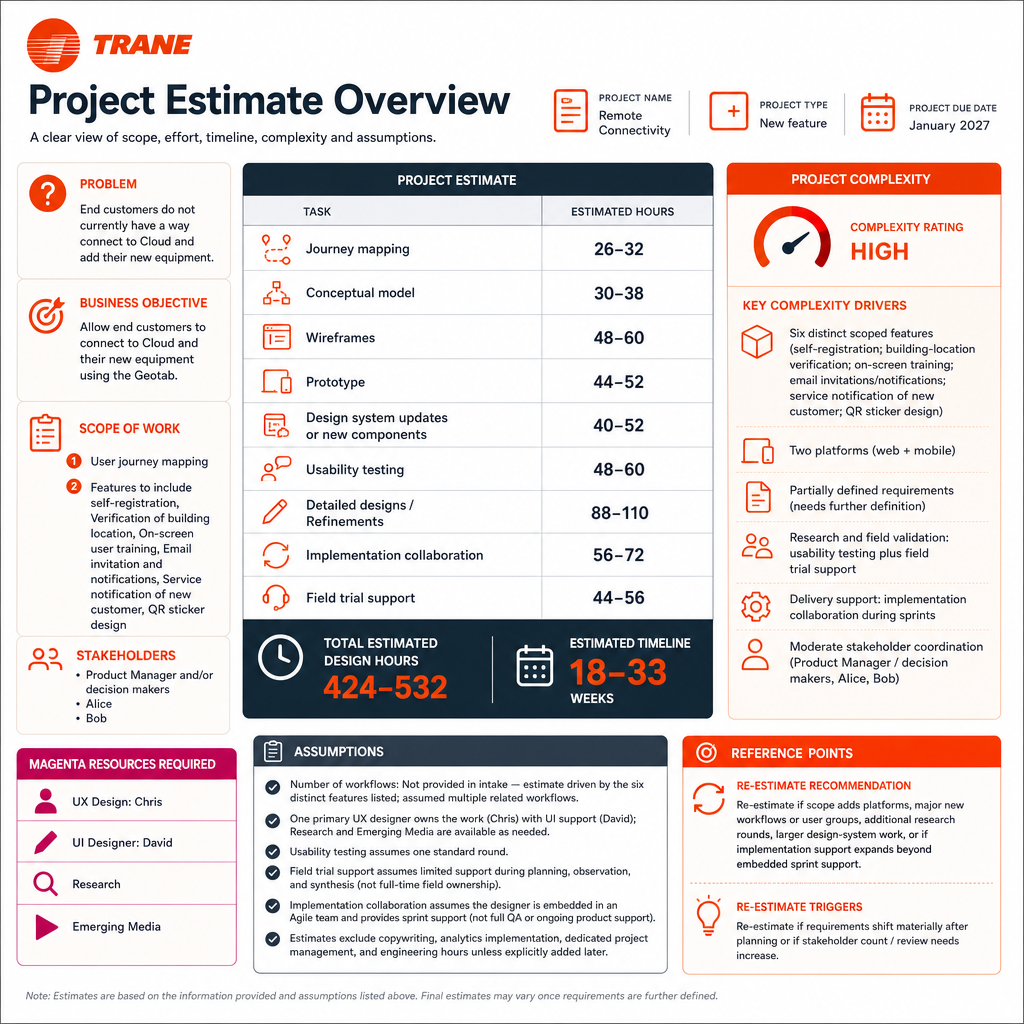

In [8]:
from openai import OpenAI
from IPython.display import display, Image
import base64

client = OpenAI()

prompt = """Modern-style clean infographic with Trane colors clearly explaining the key elements of this estimate provided."""

resultImg = client.images.generate(
    model="gpt-image-2",
    prompt=prompt+result,
    size="1024x1024"
)

# Decode image data
image_base64 = resultImg.data[0].b64_json
image_bytes = base64.b64decode(image_base64)

#Save to file
filename="design_estimate.png"
with open(filename, "wb") as f:
    f.write(image_bytes)

# Display inline
display(Image(filename=filename))